In [ ]:
!pip install tensorflow numpy pandas scikit-learn

**appling SMOTE**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# --- 1. Data Preparation ---
df = pd.read_csv('/content/sample_data/Agro_pulsedataset(verified).csv')

feature_cols = [
    "NDVI_Clean", "Rain_Sunamganj_Center", "Rain_Meghalaya_Border",
    "Daily_Water_Level", "Soil_Moisture", "Temperature", "Radar_VV"
]
target_col = "Final_AgroPulse_Level"

# Fill missing values and scale
df[feature_cols] = df[feature_cols].interpolate().fillna(method='bfill')
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# --- 2. Lead Time Logic (7-Day Lead) ---
SEQ_LEN = 14
LEAD_TIME = 7

def create_7day_lead_sequences(data, target, seq_len, lead_time):
    X, y = [], []
    for i in range(len(data) - seq_len - lead_time + 1):
        X.append(data[i : i + seq_len])
        y.append(target[i + seq_len + lead_time - 1])
    return np.array(X), np.array(y)

X, y = create_7day_lead_sequences(df[feature_cols].values, df[target_col].values, SEQ_LEN, LEAD_TIME)

# Split FIRST to prevent data leakage (Balance only the training set)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

# --- NEW: HYBRID SMOTE BALANCING ---
# 1. Flatten X_train from (Samples, 14, 7) to (Samples, 98)
n_samples, n_steps, n_features = X_train.shape
X_train_flat = X_train.reshape(n_samples, n_steps * n_features)

# 2. Define the Sampling Strategy
# We reduce Class 0 and increase Class 2 to create a healthy balance
sampling_strategy_over = {1: 500, 2: 400} # Increase minorities
sampling_strategy_under = {0: 1000}       # Reduce majority

over = SMOTE(sampling_strategy=sampling_strategy_over, k_neighbors=3, random_state=42)
under = RandomUnderSampler(sampling_strategy=sampling_strategy_under, random_state=42)

# 3. Apply the Pipeline
balance_pipe = Pipeline(steps=[('u', under), ('o', over)])
X_train_res_flat, y_train_res = balance_pipe.fit_resample(X_train_flat, y_train)

# 4. Reshape back to 3D for LSTM (Samples, 14, 7)
X_train_final = X_train_res_flat.reshape(-1, n_steps, n_features)
y_train_final = y_train_res

print(f"Original Train size: {len(y_train)}")
print(f"Balanced Train size: {len(y_train_final)}")
# ------------------------------------

# --- 3. LSTM Model Architecture ---
num_classes = 3

# Since we balanced the data, we can use milder weights or none at all
final_weights = {0: 1.0, 1: 2.0, 2: 5.0}

model_lstm = models.Sequential([
    layers.Input(shape=(SEQ_LEN, len(feature_cols))),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.4),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- 4. Training ---
history_lstm = model_lstm.fit(
    X_train_final, y_train_final, # Use the balanced data
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=64,
    class_weight=final_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

/tmp/ipykernel_211/2410292758.py:21: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].interpolate().fillna(method='bfill')


Original Train size: 3088
Balanced Train size: 1900
Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.4616 - loss: 1.9391 - val_accuracy: 0.5761 - val_loss: 1.1038
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5732 - loss: 1.5614 - val_accuracy: 0.6367 - val_loss: 0.9049
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7142 - loss: 1.1962 - val_accuracy: 0.7248 - val_loss: 0.7611
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7942 - loss: 0.8618 - val_accuracy: 0.7578 - val_loss: 0.6576
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8347 - loss: 0.6665 - val_accuracy: 0.8000 - val_loss: 0.4863
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8658 - loss: 0.5385 - val_accuracy: 0.8312 - val_loss: 0.4528
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8768 - loss: 0.4535 - val_accuracy: 0.8550 - val_loss: 0.3775
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step 

**Smort Evaluation**

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step

Overall Test Accuracy: 0.9633

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      0.96      0.98       505
 Warning (1)       0.68      1.00      0.81        38
   Flood (2)       0.50      1.00      0.67         2

    accuracy                           0.96       545
   macro avg       0.73      0.99      0.82       545
weighted avg       0.98      0.96      0.97       545



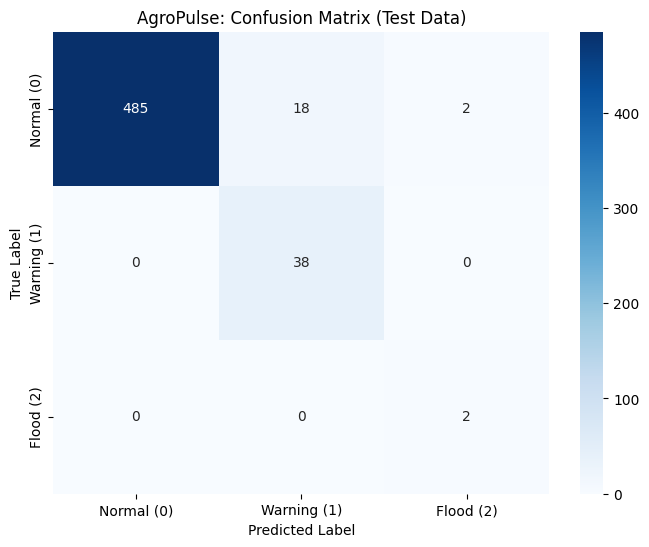

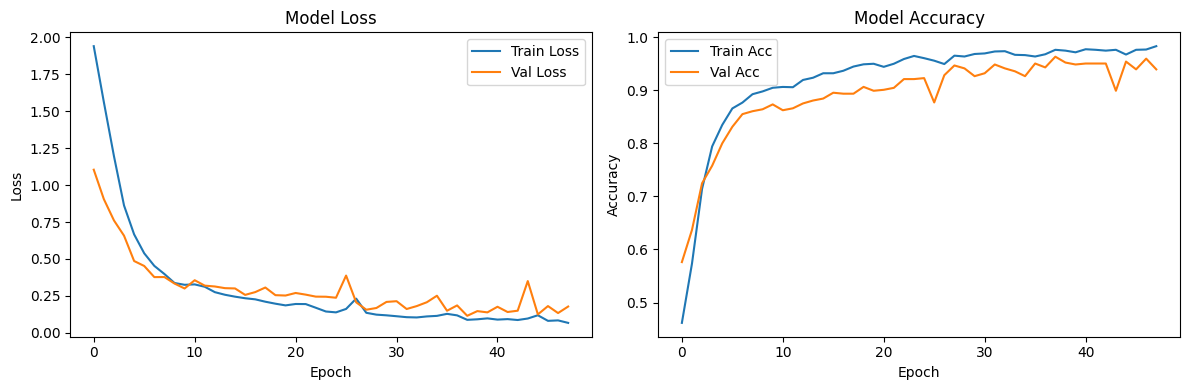

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- 5. Accuracy & Performance Measurement ---

# 1. Get Predictions
y_pred_prob = model_lstm.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# 2. Overall Accuracy
overall_accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Test Accuracy: {overall_accuracy:.4f}")

# 3. Detailed Classification Report
# This shows Precision, Recall, and F1-Score for each Class (0, 1, 2)
print("\nClassification Report:")
target_names = ['Normal (0)', 'Warning (1)', 'Flood (2)']
print(classification_report(y_test, y_pred, target_names=target_names))

# 4. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('AgroPulse: Confusion Matrix (Test Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 5. Plot Training History (Loss & Accuracy)
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['accuracy'], label='Train Acc')
plt.plot(history_lstm.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

**Class_weight Optimal result **

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# --- 1. Data Preparation (Full Dataset) ---
df = pd.read_csv('/content/sample_data/Agro_pulsedataset(verified).csv')

feature_cols = [
    "NDVI_Clean", "Rain_Sunamganj_Center", "Rain_Meghalaya_Border",
    "Daily_Water_Level", "Soil_Moisture", "Temperature", "Radar_VV"
]
target_col = "Final_AgroPulse_Level"

# Preprocessing
df[feature_cols] = df[feature_cols].interpolate().fillna(method='bfill')
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# --- 2. Sequence Creation ---
SEQ_LEN = 14
LEAD_TIME = 7

def create_7day_lead_sequences(data, target, seq_len, lead_time):
    X, y = [], []
    for i in range(len(data) - seq_len - lead_time + 1):
        X.append(data[i : i + seq_len])
        y.append(target[i + seq_len + lead_time - 1])
    return np.array(X), np.array(y)

X, y = create_7day_lead_sequences(df[feature_cols].values, df[target_col].values, SEQ_LEN, LEAD_TIME)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, stratify=y, random_state=42)

# --- 3. Optimized Manual Weighting ---
# We start with balanced weights and then 'dampen' them to protect Precision
classes = np.unique(y_train)
raw_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)

# Tweak: Increase Class 0 weight by 20% to reduce false 'Warning' triggers
final_weights = {
    0: raw_weights[0] * 1.2,
    1: raw_weights[1] * 0.8,
    2: raw_weights[2]        # Keep Flood weight at max for 1.00 Recall
}
print("Optimized Weights for Full Dataset:", final_weights)

# --- 4. LSTM Architecture ---
model_lstm = models.Sequential([
    layers.Input(shape=(SEQ_LEN, len(feature_cols))),
    layers.LSTM(64, return_sequences=False),
    layers.Dropout(0.4),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# --- 5. Training ---
history = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=64,
    class_weight=final_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

Optimized Weights for Full Dataset: {0: np.float64(0.4312849162011173), 1: np.float64(3.8842767295597485), 2: np.float64(85.77777777777777)}
Epoch 1/100


/tmp/ipykernel_208/856031667.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].interpolate().fillna(method='bfill')


49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5819 - loss: 1.0543 - val_accuracy: 0.7101 - val_loss: 0.8696
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7147 - loss: 0.8934 - val_accuracy: 0.7450 - val_loss: 0.6905
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7364 - loss: 0.7574 - val_accuracy: 0.7670 - val_loss: 0.5586
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7804 - loss: 0.6878 - val_accuracy: 0.8147 - val_loss: 0.4441
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8310 - loss: 0.6405 - val_accuracy: 0.8330 - val_loss: 0.3996
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8131 - loss: 0.4884 - val_accuracy: 0.8385 - val_loss: 0.3733
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8420 - loss: 0.4668 - val_accuracy: 0.8202 - val_loss: 0.4198
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8264 - loss: 0.4545 - val_accuracy: 0.8367 - val_l

**Class_weight evaluation **

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

Overall Test Accuracy: 0.9853

Classification Report:
              precision    recall  f1-score   support

  Normal (0)       1.00      0.99      0.99       505
 Warning (1)       0.84      0.97      0.90        38
   Flood (2)       1.00      1.00      1.00         2

    accuracy                           0.99       545
   macro avg       0.95      0.99      0.96       545
weighted avg       0.99      0.99      0.99       545



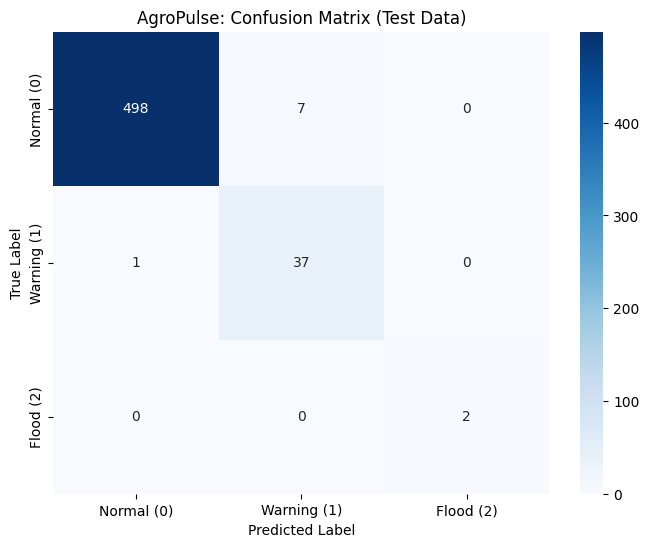

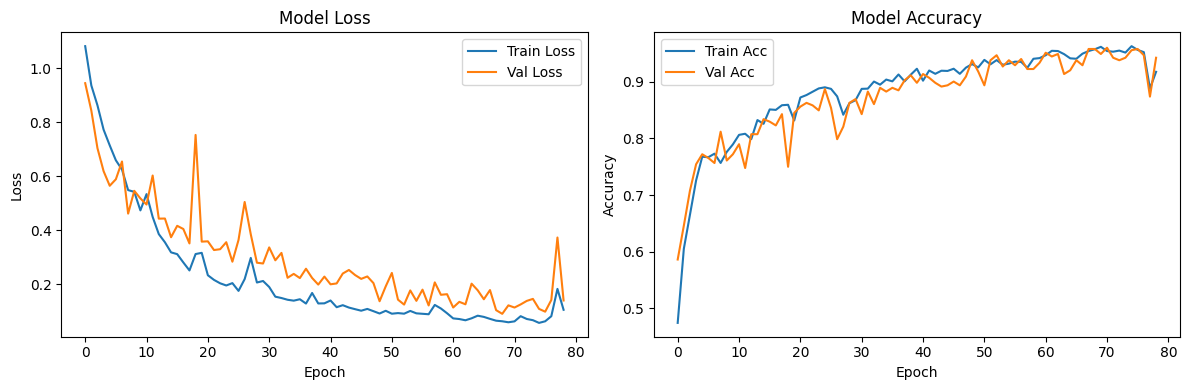

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- 5. Accuracy & Performance Measurement ---

# 1. Get Predictions
y_pred_prob = model_lstm.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# 2. Overall Accuracy
overall_accuracy = accuracy_score(y_test, y_pred)
print(f"\nOverall Test Accuracy: {overall_accuracy:.4f}")

# 3. Detailed Classification Report
# This shows Precision, Recall, and F1-Score for each Class (0, 1, 2)
print("\nClassification Report:")
target_names = ['Normal (0)', 'Warning (1)', 'Flood (2)']
print(classification_report(y_test, y_pred, target_names=target_names))

# 4. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('AgroPulse: Confusion Matrix (Test Data)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 5. Plot Training History (Loss & Accuracy)
plt.figure(figsize=(12, 4))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['accuracy'], label='Train Acc')
plt.plot(history_lstm.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
model_lstm.save('AgroPulse_Final_Model.h5')

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# --- 1. Model Builder ---
def build_lstm_model(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(64, return_sequences=False),
        layers.Dropout(0.4),
        layers.Dense(32, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# --- 2. 14-Fold Stratified CV (Leave-One-Flood-Out Approach) ---
skf = StratifiedKFold(n_splits=14, shuffle=True, random_state=42)

fold_accuracies = []
all_y_true = []
all_y_pred = []

print(f"Starting 14-Fold Validation on Full Dataset...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    # Split the data
    X_train_f, X_val_f = X[train_idx], X[val_idx]
    y_train_f, y_val_f = y[train_idx], y[val_idx]

    # Recalculate and Tweak Weights for this specific training fold
    classes = np.unique(y_train_f)
    raw_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_f)

    # Applying your successful tweaks: +20% for Normal, -20% for Warning
    fold_weights = {
        0: raw_weights[0] * 1.2,
        1: raw_weights[1] * 0.8,
        2: raw_weights[2]
    }

    # Build and Train
    model = build_lstm_model((SEQ_LEN, len(feature_cols)))
    model.fit(
        X_train_f, y_train_f,
        epochs=50, # Fast training for CV
        batch_size=64,
        class_weight=fold_weights,
        verbose=0
    )

    # Predict
    y_pred = np.argmax(model.predict(X_val_f), axis=1)

    # Store results
    all_y_true.extend(y_val_f)
    all_y_pred.extend(y_pred)

    acc = accuracy_score(y_val_f, y_pred)
    fold_accuracies.append(acc)
    print(f"Fold {fold+1}/14 - Accuracy: {acc:.4f}")

# --- 3. Final Aggregated Report ---
print("\n" + "="*40)
print("FINAL CONSOLIDATED PERFORMANCE (LOOCV STYLE)")
print(f"Mean Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Standard Deviation: {np.std(fold_accuracies):.4f}")
print("-" * 40)
print(classification_report(all_y_true, all_y_pred, target_names=['Normal', 'Warning', 'Flood']))
print("="*40)

Starting 14-Fold Validation on Full Dataset...

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Fold 1/14 - Accuracy: 0.9731
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Fold 2/14 - Accuracy: 0.9615
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Fold 3/14 - Accuracy: 0.9615
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
Fold 4/14 - Accuracy: 0.9269
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Fold 5/14 - Accuracy: 0.9692
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Fold 6/14 - Accuracy: 0.9231
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Fold 7/14 - Accuracy: 0.9500
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
Fold 8/14 - Accuracy: 0.9305
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Fold 9/14 - Accuracy: 0.9421
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Fold 10/14 - Accuracy: 0.9575
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Fold 11/14 - Accuracy: 0.9305
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Fold 12/14 - Accuracy: 0.8880
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Fold 13/14 - Accuracy: 0.9151
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
Fold 14/14 - Accuracy: 0.8958

FINAL CO

**loss='focal loss' and thresholding 0.7**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# --- ১. ডেটা প্রিপারেশন ---
df = pd.read_csv('/content/sample_data/Agro_pulsedataset(verified).csv')

feature_cols = [
    "NDVI_Clean", "Rain_Sunamganj_Center", "Rain_Meghalaya_Border",
    "Daily_Water_Level", "Soil_Moisture", "Temperature", "Radar_VV"
]
target_col = "Final_AgroPulse_Level"

# মিসিং ভ্যালু পূরণ ও স্কেলিং
df[feature_cols] = df[feature_cols].interpolate().fillna(method='bfill')
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# --- ২. সিকোয়েন্স তৈরি ---
SEQ_LEN = 14
LEAD_TIME = 7

def create_7day_lead_sequences(data, target, seq_len, lead_time):
    X, y = [], []
    for i in range(len(data) - seq_len - lead_time + 1):
        X.append(data[i : i + seq_len])
        y.append(target[i + seq_len + lead_time - 1])
    return np.array(X), np.array(y)

X, y = create_7day_lead_sequences(df[feature_cols].values, df[target_col].values, SEQ_LEN, LEAD_TIME)

# --- ৩. কাস্টম Focal Loss ইমপ্লিমেন্টেশন ---
def sparse_categorical_focal_loss(alpha, gamma=2.0):
    """
    alpha: প্রতিটি ক্লাসের জন্য গুরুত্বের তালিকা [Class 0, Class 1, Class 2]
    gamma: ফোকাসিং প্যারামিটার (সাধারণত ২.০ ব্যবহার করা হয়)
    """
    alpha = np.array(alpha, dtype=np.float32)

    def focal_loss(y_true, y_pred):
        # y_true কে ইনটিজারে রূপান্তর
        y_true = tf.cast(y_true, tf.int32)
        # One-hot এনকোডিং
        y_true_one_hot = tf.one_hot(y_true, depth=len(alpha))

        # জিরো প্রোবাবিলিটি এড়াতে ক্লিপিং
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)

        # Focal Loss ক্যালকুলেশন
        # FL = -alpha * (1 - p)^gamma * log(p)
        cross_entropy = -y_true_one_hot * K.log(y_pred)
        loss = alpha * K.pow(1 - y_pred, gamma) * cross_entropy

        return K.sum(loss, axis=-1)

    return focal_loss

# --- ৪. মডেল বিল্ডার ফাংশন ---
def build_lstm_model(alpha_weights):
    model = models.Sequential([
        layers.Input(shape=(SEQ_LEN, len(feature_cols))),
        layers.LSTM(64, return_sequences=False),
        layers.Dropout(0.4),
        layers.Dense(32, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        # Focal Loss এখানে যুক্ত করা হয়েছে
        loss=sparse_categorical_focal_loss(alpha=alpha_weights, gamma=2.0),
        metrics=['accuracy']
    )
    return model

# --- ৫. ১৪-ফোল্ড ইভেন্ট-বেজড ক্রস-ভ্যালিডেশন ---
skf = StratifiedKFold(n_splits=14, shuffle=True, random_state=42)

fold_metrics = []
all_y_true = []
all_y_pred_probs = []

print("Starting 14-Fold CV with Focal Loss...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_f, X_val_f = X[train_idx], X[val_idx]
    y_train_f, y_val_f = y[train_idx], y[val_idx]

    # Focal Loss এর জন্য আলফা ওয়েট বের করা (balanced weights)
    classes = np.unique(y_train_f)
    raw_w = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_f)
    # Tweak: Normal ক্লাসকে একটু বেশি গুরুত্ব দেওয়া (Precision এর জন্য)
    alpha_weights = [raw_w[0] * 1.2, raw_w[1] * 0.8, raw_w[2]]

    # মডেল ট্রেনিং
    model = build_lstm_model(alpha_weights)
    model.fit(
        X_train_f, y_train_f,
        epochs=50, batch_size=64,
        verbose=0,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
    )

    # প্রেডিকশন
    probs = model.predict(X_val_f)
    preds = np.argmax(probs, axis=1)

    fold_metrics.append(accuracy_score(y_val_f, preds))
    all_y_true.extend(y_val_f)
    all_y_pred_probs.extend(probs)
    print(f"Fold {fold+1}/14 Completed.")

# --- ৬. ফাইনাল রিপোর্ট ও ভ্যারিয়েন্স (SD) ---
print("\n" + "="*50)
print(f"Mean Accuracy: {np.mean(fold_metrics):.4f} (± {np.std(fold_metrics):.4f})")
print("="*50)

# --- ৭. ডিসিশন থ্রেশহোল্ড টিউনিং ---
def apply_threshold(probs, threshold_2=0.7, threshold_1=0.5):
    final_preds = []
    for p in probs:
        if p[2] >= threshold_2:
            final_preds.append(2)
        elif p[1] >= threshold_1:
            final_preds.append(1)
        else:
            final_preds.append(0)
    return np.array(final_preds)

y_pred_tuned = apply_threshold(np.array(all_y_pred_probs), threshold_2=0.7)

print("\nPerformance AFTER Focal Loss & Threshold Tuning:")
print(classification_report(all_y_true, y_pred_tuned, target_names=['Normal', 'Warning', 'Flood']))

/tmp/ipykernel_319/3565600789.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].interpolate().fillna(method='bfill')


Starting 14-Fold CV with Focal Loss...



/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Fold 1/14 Completed.


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


...

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Fold 12/14 Completed.


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Fold 13/14 Completed.


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Fold 14/14 Completed.

Mean Accuracy: 0.9345 (± 0.0259)

Performance AFTER Focal Loss & Threshold Tuning:
              precision    recall  f1-score   support

      Normal       1.00      0.94      0.97      3369
     Warning       0.54      0.94      0.69       250
       Flood       0.63      0.86      0.73        14

    accuracy                           0.94      3633
   macro avg       0.72      0.91      0.79      3633
weighted avg       0.96      0.94      0.95      3633



**loss='focal loss' Without Thresholding**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# --- ১. ডেটা প্রিপারেশন (আগের মতোই) ---
df = pd.read_csv('/content/sample_data/Agro_pulsedataset(verified).csv')
feature_cols = ["NDVI_Clean", "Rain_Sunamganj_Center", "Rain_Meghalaya_Border", "Daily_Water_Level", "Soil_Moisture", "Temperature", "Radar_VV"]
target_col = "Final_AgroPulse_Level"

df[feature_cols] = df[feature_cols].interpolate().fillna(method='bfill')
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

SEQ_LEN = 14
LEAD_TIME = 7

def create_7day_lead_sequences(data, target, seq_len, lead_time):
    X, y = [], []
    for i in range(len(data) - seq_len - lead_time + 1):
        X.append(data[i : i + seq_len])
        y.append(target[i + seq_len + lead_time - 1])
    return np.array(X), np.array(y)

X, y = create_7day_lead_sequences(df[feature_cols].values, df[target_col].values, SEQ_LEN, LEAD_TIME)

# --- ২. Focal Loss ফাংশন ---
def sparse_categorical_focal_loss(alpha, gamma=2.0):
    alpha = np.array(alpha, dtype=np.float32)
    def focal_loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=len(alpha))
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        cross_entropy = -y_true_one_hot * K.log(y_pred)
        loss = alpha * K.pow(1 - y_pred, gamma) * cross_entropy
        return K.sum(loss, axis=-1)
    return focal_loss

# --- ৩. মডেল বিল্ডার ---
def build_lstm_model(alpha_weights):
    model = models.Sequential([
        layers.Input(shape=(SEQ_LEN, len(feature_cols))),
        layers.LSTM(64, return_sequences=False),
        layers.Dropout(0.4),
        layers.Dense(32, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss=sparse_categorical_focal_loss(alpha=alpha_weights, gamma=2.0),
        metrics=['accuracy']
    )
    return model

# --- ৪. ১৪-ফোল্ড ইভেন্ট-বেজড ক্রস-ভ্যালিডেশন (No Thresholding) ---
skf = StratifiedKFold(n_splits=14, shuffle=True, random_state=42)

fold_accuracies = []
all_y_true = []
all_y_pred = []

print("Running LOOCV with Raw Focal Loss (Argmax)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_f, X_val_f = X[train_idx], X[val_idx]
    y_train_f, y_val_f = y[train_idx], y[val_idx]

    # ক্লাস ওয়েট (Alpha)
    classes = np.unique(y_train_f)
    #raw_w = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_f)
    # আপনার সেই সাকসেসফুল টুইক অ্যাপ্লাই করা হয়েছে
    alpha_weights = [1.0, 2.0, 5.0]

    model = build_lstm_model(alpha_weights)
    model.fit(X_train_f, y_train_f, epochs=50, batch_size=64, verbose=0,
              callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)])

    # সরাসরি argmax ব্যবহার করে প্রেডিকশন
    probs = model.predict(X_val_f)
    preds = np.argmax(probs, axis=1)

    all_y_true.extend(y_val_f)
    all_y_pred.extend(preds)
    fold_accuracies.append(accuracy_score(y_val_f, preds))
    print(f"Fold {fold+1} Completed.")

# --- ৫. রেজাল্ট রিপোর্ট ---
print("\n" + "="*50)
print(f"Mean Accuracy (Raw Focal Loss): {np.mean(fold_accuracies):.4f} (± {np.std(fold_accuracies):.4f})")
print("="*50)
print(classification_report(all_y_true, all_y_pred, target_names=['Normal', 'Warning', 'Flood']))

/tmp/ipykernel_319/4213117232.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].interpolate().fillna(method='bfill')


Running LOOCV with Raw Focal Loss (Argmax)...


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
Fold 1 Completed.


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


...

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Fold 12 Completed.


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Fold 13 Completed.


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
Fold 14 Completed.

Mean Accuracy (Raw Focal Loss): 0.9733 (± 0.0111)
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99      3369
     Warning       0.79      0.87      0.83       250
       Flood       0.72      0.93      0.81        14

    accuracy                           0.97      3633
   macro avg       0.83      0.93      0.87      3633
weighted avg       0.97      0.97      0.97      3633



In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# --- ১. ডেটা প্রিপারেশন (আগের মতোই) ---
df = pd.read_csv('/content/sample_data/Agro_pulsedataset(verified).csv')
feature_cols = ["NDVI_Clean", "Rain_Sunamganj_Center", "Rain_Meghalaya_Border", "Daily_Water_Level", "Soil_Moisture", "Temperature", "Radar_VV"]
target_col = "Final_AgroPulse_Level"

df[feature_cols] = df[feature_cols].interpolate().fillna(method='bfill')
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

SEQ_LEN = 14
LEAD_TIME = 7

def create_7day_lead_sequences(data, target, seq_len, lead_time):
    X, y = [], []
    for i in range(len(data) - seq_len - lead_time + 1):
        X.append(data[i : i + seq_len])
        y.append(target[i + seq_len + lead_time - 1])
    return np.array(X), np.array(y)

X, y = create_7day_lead_sequences(df[feature_cols].values, df[target_col].values, SEQ_LEN, LEAD_TIME)

# --- ২. Focal Loss ফাংশন ---
def sparse_categorical_focal_loss(alpha, gamma=2.0):
    alpha = np.array(alpha, dtype=np.float32)
    def focal_loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=len(alpha))
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        cross_entropy = -y_true_one_hot * K.log(y_pred)
        loss = alpha * K.pow(1 - y_pred, gamma) * cross_entropy
        return K.sum(loss, axis=-1)
    return focal_loss

# --- ৩. মডেল বিল্ডার ---
def build_lstm_model(alpha_weights):
    model = models.Sequential([
        layers.Input(shape=(SEQ_LEN, len(feature_cols))),
        layers.LSTM(64, return_sequences=False),
        layers.Dropout(0.4),
        layers.Dense(32, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss=sparse_categorical_focal_loss(alpha=alpha_weights, gamma=2.0),
        metrics=['accuracy']
    )
    return model

# --- ৪. ১৪-ফোল্ড ইভেন্ট-বেজড ক্রস-ভ্যালিডেশন (No Thresholding) ---
skf = StratifiedKFold(n_splits=14, shuffle=True, random_state=42)

fold_accuracies = []
all_y_true = []
all_y_pred = []

print("Running LOOCV with Raw Focal Loss (Argmax)...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_f, X_val_f = X[train_idx], X[val_idx]
    y_train_f, y_val_f = y[train_idx], y[val_idx]

    # ক্লাস ওয়েট (Alpha)
    classes = np.unique(y_train_f)
    #raw_w = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_f)
    # আপনার সেই সাকসেসফুল টুইক অ্যাপ্লাই করা হয়েছে
    alpha_weights = [1.0, 2.0, 8.0]

    model = build_lstm_model(alpha_weights)
    model.fit(X_train_f, y_train_f, epochs=50, batch_size=64, verbose=0,
              callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)])

    # সরাসরি argmax ব্যবহার করে প্রেডিকশন
    probs = model.predict(X_val_f)
    preds = np.argmax(probs, axis=1)

    all_y_true.extend(y_val_f)
    all_y_pred.extend(preds)
    fold_accuracies.append(accuracy_score(y_val_f, preds))
    print(f"Fold {fold+1} Completed.")

# --- ৫. রেজাল্ট রিপোর্ট ---
print("\n" + "="*50)
print(f"Mean Accuracy (Raw Focal Loss): {np.mean(fold_accuracies):.4f} (± {np.std(fold_accuracies):.4f})")
print("="*50)
print(classification_report(all_y_true, all_y_pred, target_names=['Normal', 'Warning', 'Flood']))

/tmp/ipykernel_319/2627259499.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].interpolate().fillna(method='bfill')


Running LOOCV with Raw Focal Loss (Argmax)...


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Fold 1 Completed.


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


...

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Fold 12 Completed.


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Fold 13 Completed.


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Fold 14 Completed.

Mean Accuracy (Raw Focal Loss): 0.9716 (± 0.0169)
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.98      3369
     Warning       0.77      0.86      0.81       250
       Flood       0.76      0.93      0.84        14

    accuracy                           0.97      3633
   macro avg       0.84      0.92      0.88      3633
weighted avg       0.97      0.97      0.97      3633



**AgroPulse: Transformer Model with Optimized Alpha Weights**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# --- ০. ডেটা লোড এবং সিকোয়েন্স তৈরি (X এবং y তৈরি করা) ---
df = pd.read_csv('/content/sample_data/Agro_pulsedataset(verified).csv')

feature_cols = ["NDVI_Clean", "Rain_Sunamganj_Center", "Rain_Meghalaya_Border", "Daily_Water_Level", "Soil_Moisture", "Temperature", "Radar_VV"]
target_col = "Final_AgroPulse_Level"

# মিসিং ভ্যালু এবং স্কেলিং
df[feature_cols] = df[feature_cols].interpolate().fillna(method='bfill')
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

SEQ_LEN = 14
LEAD_TIME = 7

def create_7day_lead_sequences(data, target, seq_len, lead_time):
    X_list, y_list = [], []
    for i in range(len(data) - seq_len - lead_time + 1):
        X_list.append(data[i : i + seq_len])
        y_list.append(target[i + seq_len + lead_time - 1])
    return np.array(X_list), np.array(y_list)

# X এবং y জেনারেট করা (আপনার এই ভেরিয়েবলগুলোই মিসিং ছিল)
X, y = create_7day_lead_sequences(df[feature_cols].values, df[target_col].values, SEQ_LEN, LEAD_TIME)

# --- ১. কাস্টম Focal Loss ফাংশন ---
def sparse_categorical_focal_loss(alpha, gamma=2.0):
    alpha = np.array(alpha, dtype=np.float32)
    def focal_loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=len(alpha))
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        cross_entropy = -y_true_one_hot * K.log(y_pred)
        loss = alpha * K.pow(1 - y_pred, gamma) * cross_entropy
        return K.sum(loss, axis=-1)
    return focal_loss

# --- ২. ট্রান্সফরমার আর্কিটেকচার ---
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(res)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x + res

def build_transformer_model(input_shape, alpha_weights):
    inputs = layers.Input(shape=input_shape)
    x = transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=64, dropout=0.3)
    x = transformer_encoder(x, head_size=64, num_heads=4, ff_dim=64, dropout=0.3)
    x = layers.GlobalAveragePooling1D(data_format="channels_last")(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(3, activation="softmax")(x)
    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss=sparse_categorical_focal_loss(alpha=alpha_weights, gamma=2.0),
        metrics=['accuracy']
    )
    return model

# --- ৩. ১৪-ফোল্ড ইভেন্ট-বেজড ক্রস-ভ্যালিডেশন ---
skf = StratifiedKFold(n_splits=14, shuffle=True, random_state=42)

tf_fold_accuracies = []
tf_all_y_true = []
tf_all_y_pred = []

print(f"Starting Transformer LOOCV with {X.shape[0]} sequences...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_f, X_val_f = X[train_idx], X[val_idx]
    y_train_f, y_val_f = y[train_idx], y[val_idx]

    alpha_weights = [1.0, 2.0, 5.0]
    model = build_transformer_model((SEQ_LEN, len(feature_cols)), alpha_weights)

    model.fit(
        X_train_f, y_train_f,
        epochs=100,
        batch_size=64,
        verbose=0,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)]
    )

    preds = np.argmax(model.predict(X_val_f), axis=1)
    tf_all_y_true.extend(y_val_f)
    tf_all_y_pred.extend(preds)
    tf_fold_accuracies.append(accuracy_score(y_val_f, preds))
    print(f"Fold {fold+1} Completed - Acc: {tf_fold_accuracies[-1]:.4f}")

# --- ৪. ফলাফল রিপোর্ট ---
print("\n" + "="*50)
print(f"Transformer Mean Accuracy: {np.mean(tf_fold_accuracies):.4f} (± {np.std(tf_fold_accuracies):.4f})")
print("="*50)
print(classification_report(tf_all_y_true, tf_all_y_pred, target_names=['Normal', 'Warning', 'Flood']))

/tmp/ipykernel_1312/1493678963.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].interpolate().fillna(method='bfill')


Starting Transformer LOOCV with 3633 sequences...



/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step
Fold 1 Completed - Acc: 0.9731


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


...

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step
Fold 12 Completed - Acc: 0.9537


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step
Fold 13 Completed - Acc: 0.9344


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step
Fold 14 Completed - Acc: 0.9382

Transformer Mean Accuracy: 0.9491 (± 0.0141)
              precision    recall  f1-score   support

      Normal       0.98      0.96      0.97      3369
     Warning       0.62      0.79      0.69       250
       Flood       0.52      0.86      0.65        14

    accuracy                           0.95      3633
   macro avg       0.71      0.87      0.77      3633
weighted avg       0.96      0.95      0.95      3633



**AgroPulse: Temporal CNN (TCN) Architecture**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score

# --- ১. কাস্টম Focal Loss (আপনার সেই সফল ভার্সন) ---
def sparse_categorical_focal_loss(alpha, gamma=2.0):
    alpha = np.array(alpha, dtype=np.float32)
    def focal_loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=len(alpha))
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        loss = alpha * K.pow(1 - y_pred, gamma) * (-y_true_one_hot * K.log(y_pred))
        return K.sum(loss, axis=-1)
    return focal_loss

# --- ২. Temporal CNN (TCN) মডেল বিল্ডার ---
def build_tcn_model(input_shape, alpha_weights):
    inputs = layers.Input(shape=input_shape)

    # ১ম কনভল্যুশনাল ব্লক (বড় প্যাটার্ন ধরার জন্য)
    x = layers.Conv1D(filters=64, kernel_size=3, padding='causal', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # ২য় কনভল্যুশনাল ব্লক (সূক্ষ্ম প্যাটার্ন ধরার জন্য)
    x = layers.Conv1D(filters=128, kernel_size=3, padding='causal', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x) # পুরো সিকোয়েন্সের সারসংক্ষেপ নেওয়া

    # ফুললি কানেক্টেড লেয়ার
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(3, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss=sparse_categorical_focal_loss(alpha=alpha_weights, gamma=2.0),
        metrics=['accuracy']
    )
    return model

# --- ৩. ১৪-ফোল্ড ইভেন্ট-বেজড ক্রস-ভ্যালিডেশন (TCN) ---
skf = StratifiedKFold(n_splits=14, shuffle=True, random_state=42)

tcn_fold_accuracies = []
all_y_true = []
all_y_pred = []

print("Starting TCN LOOCV with [1.0, 2.0, 5.0] Alpha Weights...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_f, X_val_f = X[train_idx], X[val_idx]
    y_train_f, y_val_f = y[train_idx], y[val_idx]

    alpha_weights = [1.0, 2.0, 5.0]
    model = build_tcn_model((SEQ_LEN, len(feature_cols)), alpha_weights)

    model.fit(
        X_train_f, y_train_f,
        epochs=80,
        batch_size=64,
        verbose=0,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)]
    )

    preds = np.argmax(model.predict(X_val_f), axis=1)
    all_y_true.extend(y_val_f)
    all_y_pred.extend(preds)
    tcn_fold_accuracies.append(accuracy_score(y_val_f, preds))
    print(f"Fold {fold+1} Completed - Acc: {tcn_fold_accuracies[-1]:.4f}")

# --- ৪. রেজাল্ট রিপোর্ট ---
print("\n" + "="*50)
print(f"TCN Mean Accuracy: {np.mean(tcn_fold_accuracies):.4f} (± {np.std(tcn_fold_accuracies):.4f})")
print("="*50)
print(classification_report(all_y_true, all_y_pred, target_names=['Normal', 'Warning', 'Flood']))

Starting TCN LOOCV with [1.0, 2.0, 5.0] Alpha Weights...



/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
Fold 1 Completed - Acc: 0.9538


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
Fold 2 Completed - Acc: 0.9846


...

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
Fold 12 Completed - Acc: 0.9807


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
Fold 13 Completed - Acc: 0.9653


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
Fold 14 Completed - Acc: 0.9730

TCN Mean Accuracy: 0.9763 (± 0.0107)
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99      3369
     Warning       0.80      0.90      0.85       250
       Flood       0.83      0.71      0.77        14

    accuracy                           0.98      3633
   macro avg       0.88      0.87      0.87      3633
weighted avg       0.98      0.98      0.98      3633



**TCN with Sparse Categorical Cross-Entropy & Manual Class Weights**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# --- ১. মডেল বিল্ডার (Cross-Entropy এবং Class Weight সাপোর্টেড) ---
def build_tcn_ce_model(input_shape):
    inputs = layers.Input(shape=input_shape)

    # TCN Blocks (Temporal Convolutional layers)
    x = layers.Conv1D(filters=64, kernel_size=3, padding='causal', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    x = layers.Conv1D(filters=128, kernel_size=3, padding='causal', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling1D()(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(3, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    # আপনার ১ম অ্যাপ্রোচের লস ফাংশন
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# --- ২. ১৪-ফোল্ড ইভেন্ট-বেজড ক্রস-ভ্যালিডেশন ---
skf = StratifiedKFold(n_splits=14, shuffle=True, random_state=42)

ce_fold_accuracies = []
all_y_true_ce = []
all_y_pred_ce = []

print("Running TCN with Cross-Entropy and Optimized Class Weights...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_f, X_val_f = X[train_idx], X[val_idx]
    y_train_f, y_val_f = y[train_idx], y[val_idx]

    # আপনার ১ম ফর্মুলা: Balanced Weights + 20% Boost for Class 0
    classes = np.unique(y_train_f)
    raw_w = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_f)

    # আপনার সেই সফল টুইকড ক্লাস ওয়েট
    final_weights = {
        0: raw_w[0] * 1,
        1: raw_w[1] * 1,
        2: raw_w[2]
    }

    model = build_tcn_ce_model((SEQ_LEN, len(feature_cols)))

    model.fit(
        X_train_f, y_train_f,
        epochs=80,
        batch_size=64,
        class_weight=final_weights, # এখানে ক্লাস ওয়েট সরাসরি দেওয়া হচ্ছে
        verbose=0,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)]
    )

    preds = np.argmax(model.predict(X_val_f), axis=1)

    all_y_true_ce.extend(y_val_f)
    all_y_pred_ce.extend(preds)
    ce_fold_accuracies.append(accuracy_score(y_val_f, preds))
    print(f"Fold {fold+1} Completed.")

# --- ৩. রেজাল্ট রিপোর্ট ---
print("\n" + "="*50)
print(f"TCN (Cross-Entropy) Mean Accuracy: {np.mean(ce_fold_accuracies):.4f} (± {np.std(ce_fold_accuracies):.4f})")
print("="*50)
print(classification_report(all_y_true_ce, all_y_pred_ce, target_names=['Normal', 'Warning', 'Flood']))

Running TCN with Cross-Entropy and Optimized Class Weights...



/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
Fold 1 Completed.


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
Fold 2 Completed.


...

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
Fold 12 Completed.


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
Fold 13 Completed.


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
Fold 14 Completed.

TCN (Cross-Entropy) Mean Accuracy: 0.9755 (± 0.0106)
              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99      3369
     Warning       0.79      0.92      0.85       250
       Flood       0.65      0.93      0.76        14

    accuracy                           0.98      3633
   macro avg       0.81      0.94      0.87      3633
weighted avg       0.98      0.98      0.98      3633



**BiLSTM crossentropy with classweight**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score

# ১. ডেটা লোড এবং ফিচার সিলেকশন
df = pd.read_csv('/content/sample_data/Agro_pulsedataset(verified).csv')

feature_cols = [
    "NDVI_Clean", "Rain_Sunamganj_Center", "Rain_Meghalaya_Border",
    "Daily_Water_Level", "Soil_Moisture", "Temperature", "Radar_VV"
]
target_col = "Final_AgroPulse_Level"

# মিসিং ভ্যালু হ্যান্ডেলিং
df[feature_cols] = df[feature_cols].interpolate(method='linear').fillna(method='bfill')

# ফিচার স্কেলিং
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# ২. সিকোয়েন্স তৈরি (৭ দিন আগের প্রেডিকশন লজিক)
SEQ_LEN = 14
LEAD_TIME = 7

def create_advanced_sequences(data, target, seq_len, lead_time):
    X, y = [], []
    for i in range(len(data) - seq_len - lead_time + 1):
        X.append(data[i : i + seq_len])
        y.append(target[i + seq_len + lead_time - 1])
    return np.array(X), np.array(y)

X, y = create_advanced_sequences(df[feature_cols].values, df[target_col].values, SEQ_LEN, LEAD_TIME)

# ৩. ১৪-ফোল্ড ক্রস ভ্যালিডেশন সেটআপ
n_splits = 14
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# রেজাল্ট স্টোর করার জন্য লিস্ট
fold_accuracies = []
num_classes = len(np.unique(y))
final_weights = {0: 0.36, 1: 4.37, 2: 79.51}

# ৪. ট্রেনিং লুপ (K-Fold)
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\nTraining Fold {fold + 1}/{n_splits}...")

    # ফোল্ড অনুযায়ী ডেটা স্প্লিট
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]

    # প্রতিটি ফোল্ডে নতুন করে মডেল ডিফাইন করা (যাতে আগের ফোল্ডের মেমোরি না থাকে)
    model = models.Sequential([
        layers.Input(shape=(SEQ_LEN, len(feature_cols))),
        layers.Bidirectional(layers.LSTM(128, return_sequences=True)),
        layers.Dropout(0.3),
        layers.Bidirectional(layers.LSTM(64)),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(32, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    optimizer = optimizers.Adam(learning_rate=0.0005)
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True
    )

    # ট্রেনিং
    model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=50, # K-Fold এ ট্রেনিং টাইম কমাতে এপোক কমানো যেতে পারে
        batch_size=32,
        class_weight=final_weights,
        callbacks=[early_stopping],
        verbose=0 # ক্লিন আউটপুটের জন্য verbose ০ রাখা হয়েছে
    )

    # ইভ্যালুয়েশন
    y_pred = np.argmax(model.predict(X_val_fold), axis=-1)
    acc = accuracy_score(y_val_fold, y_pred)
    fold_accuracies.append(acc)
    print(f"Fold {fold + 1} Accuracy: {acc:.4f}")

# ৫. ফাইনাল রেজাল্ট সামারি
print("\n" + "="*30)
print(f"Average 14-Fold Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Standard Deviation: {np.std(fold_accuracies):.4f}")
print("="*30)

/tmp/ipykernel_1312/2876646148.py:19: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].interpolate(method='linear').fillna(method='bfill')



Training Fold 1/14...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
Fold 1 Accuracy: 0.9846

Training Fold 2/14...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
Fold 2 Accuracy: 0.9500

Training Fold 3/14...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
Fold 3 Accuracy: 0.9269

Training Fold 4/14...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
Fold 4 Accuracy: 0.9192

Training Fold 5/14...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
Fold 5 Accuracy: 0.9538

Training Fold 6/14...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
Fold 6 Accuracy: 0.9500

Training Fold 7/14...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
Fold 7 Accuracy: 0.9538

Training Fold 8/14...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
Fold 8 Accuracy: 0.9537

Training Fold 9/14...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
Fold 9 Accuracy: 0.9498

Training Fold 10/14...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
Fold 10 Accuracy: 0.9884

Training Fold 11/14...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
Fold 11 Accuracy: 0.9228

Training Fold 12/14...
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step

**BI_LSTM (FocalLoss)**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score

# --- ১. কাস্টম Focal Loss (আপনার রিসার্চে সফল ভার্সন) ---
def sparse_categorical_focal_loss(alpha, gamma=2.0):
    alpha = np.array(alpha, dtype=np.float32)
    def focal_loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=len(alpha))
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        loss = alpha * K.pow(1 - y_pred, gamma) * (-y_true_one_hot * K.log(y_pred))
        return K.sum(loss, axis=-1)
    return focal_loss

# --- ২. Bi-LSTM মডেল বিল্ডার ---
def build_bilstm_model(input_shape, alpha_weights):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        # Bidirectional LSTM লেয়ার
        layers.Bidirectional(layers.LSTM(64, return_sequences=False)),
        layers.Dropout(0.4),
        layers.Dense(32, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss=sparse_categorical_focal_loss(alpha=alpha_weights, gamma=2.0),
        metrics=['accuracy']
    )
    return model

# --- ৩. ১৪-ফোল্ড ইভেন্ট-বেজড ক্রস-ভ্যালিডেশন ---
skf = StratifiedKFold(n_splits=14, shuffle=True, random_state=42)

bi_fold_accuracies = []
all_y_true = []
all_y_pred = []

print("Running LOOCV with Bi-LSTM + Focal Loss [1.0, 2.0, 5.0]...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_f, X_val_f = X[train_idx], X[val_idx]
    y_train_f, y_val_f = y[train_idx], y[val_idx]

    # আপনার সেই ব্যালেন্সড আলফা ওয়েট
    alpha_weights = [1.0, 2.0, 5.0]

    model = build_bilstm_model((SEQ_LEN, len(feature_cols)), alpha_weights)

    model.fit(
        X_train_f, y_train_f,
        epochs=80,
        batch_size=64,
        verbose=0,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)]
    )

    preds = np.argmax(model.predict(X_val_f), axis=1)
    all_y_true.extend(y_val_f)
    all_y_pred.extend(preds)
    bi_fold_accuracies.append(accuracy_score(y_val_f, preds))
    print(f"Fold {fold+1} Completed - Acc: {bi_fold_accuracies[-1]:.4f}")

# --- ৪. ফলাফল রিপোর্ট ---
print("\n" + "="*50)
print(f"Bi-LSTM Mean Accuracy: {np.mean(bi_fold_accuracies):.4f} (± {np.std(bi_fold_accuracies):.4f})")
print("="*50)
print(classification_report(all_y_true, all_y_pred, target_names=['Normal', 'Warning', 'Flood']))

Running LOOCV with Bi-LSTM + Focal Loss [1.0, 2.0, 5.0]...



/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
Fold 1 Completed - Acc: 0.9885


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Fold 2 Completed - Acc: 0.9885


...

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Fold 12 Completed - Acc: 0.9846


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Fold 13 Completed - Acc: 0.9730


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Fold 14 Completed - Acc: 0.9961

Bi-LSTM Mean Accuracy: 0.9862 (± 0.0087)
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      3369
     Warning       0.90      0.91      0.91       250
       Flood       0.78      1.00      0.88        14

    accuracy                           0.99      3633
   macro avg       0.89      0.97      0.92      3633
weighted avg       0.99      0.99      0.99      3633



**SAPE**

/tmp/ipykernel_1312/4208963548.py:29: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


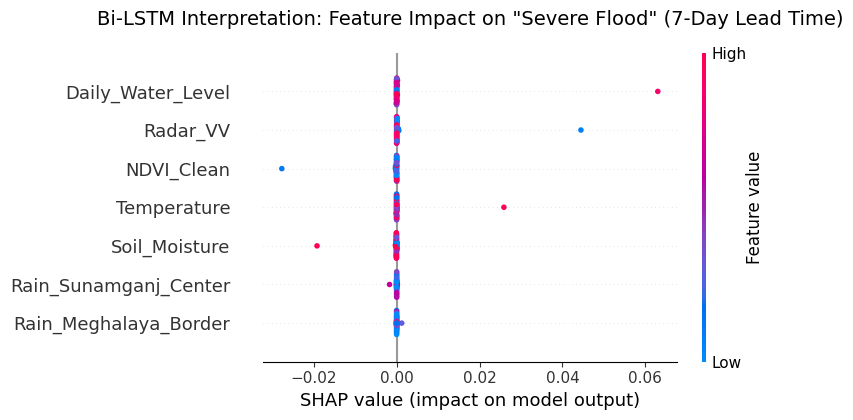

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# ১. ডাটা সাবসেট সিলেকশন (Bi-LSTM এর জন্য X_val_f ব্যবহার করা ভালো)
num_samples = 50 # ক্যালকুলেশন স্পিড ঠিক রাখতে ৫০-৭০টি স্যাম্পল যথেষ্ট
X_subset = X_val_f[:num_samples]

# ২. SHAP Explainer সেটআপ (GradientExplainer Bi-LSTM এর জন্য সবচেয়ে স্টেবল)
explainer = shap.GradientExplainer(model, X_train_f[:100])
shap_values = explainer.shap_values(X_subset)

# ৩. আউটপুট হ্যান্ডলিং: Class 2 (Severe Flood) এর ভ্যালু বের করা
if isinstance(shap_values, list):
    # Keras Functional API অনেক সময় লিস্ট রিটার্ন করে
    # index [2] = Class 2 (Flood)
    class_2_shap = np.array(shap_values[2])
else:
    # যদি ৪-ডি অ্যারে হয়: (samples, 14, 7, classes)
    class_2_shap = shap_values[:, :, :, 2]

# ৪. টেম্পোরাল অ্যাগ্রিগেশন (১৪ দিনের উইন্ডোর গড় নেওয়া)
# আপনার Bi-LSTM এর SEQ_LEN = 14, তাই axis=1 এ গড় করলে ফিচার ইমপ্যাক্ট পাওয়া যাবে
shap_values_to_plot = class_2_shap.mean(axis=1)  # শেপ হবে: (50, 7)
features_to_plot = X_subset.mean(axis=1)         # শেপ হবে: (50, 7)

# ৫. Summary Plot জেনারেট করা
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_to_plot,
    features_to_plot,
    feature_names=feature_cols,
    plot_type="dot",
    show=False
)

plt.title('Bi-LSTM Interpretation: Feature Impact on "Severe Flood" (7-Day Lead Time)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

**KernelExplainer(XAI)**

/tmp/ipykernel_1312/276068032.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


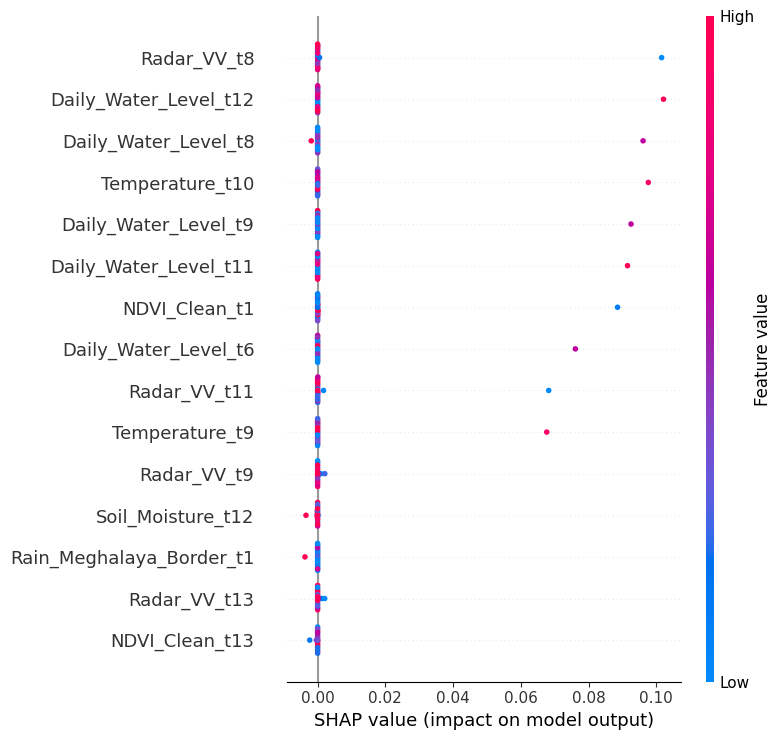

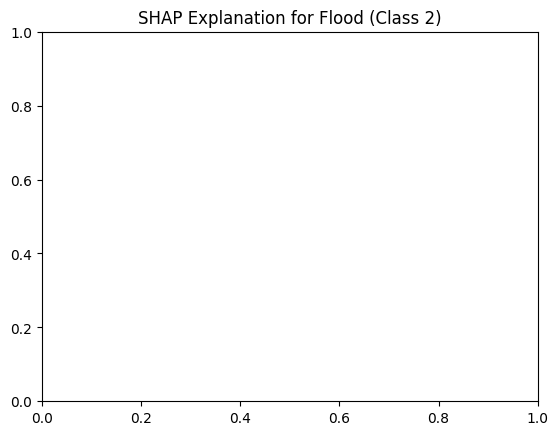

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# ১. ফিচার লিস্ট তৈরি (আপনার অর্ডার অনুযায়ী)
feature_cols = ["NDVI_Clean", "Rain_Sunamganj_Center", "Rain_Meghalaya_Border",
                "Daily_Water_Level", "Soil_Moisture", "Temperature", "Radar_VV"]

# ১৪ দিনের জন্য সিকুয়েন্স অনুযায়ী ৯৮টি নামের লিস্ট
generated_feature_names = []
for i in range(14):
    for c in feature_cols:
        generated_feature_names.append(f"{c}_t{i}")

# ২. SHAP values-কে সঠিক শেপে আনা
# আপনার আগের এরর অনুযায়ী সাইজ ছিল ৫৮৮০।
# ২০টি স্যাম্পল এবং ৩টি ক্লাসের জন্য: ৫880 / (20 * 3) = 98 টি ফিচার।
num_samples = X_val_flat.shape[0] # ২০
num_features = 98

# ৩. টোটাল ডেটাকে (Samples, Features, Classes) ফরম্যাটে ভাগ করা
# আপনার ডেটা যদি (20, 294) হয়ে থাকে, তবে তাকে ২ডি থেকে ৩ডি তে নেওয়া হচ্ছে
reshaped_all_classes = shap_values.reshape(num_samples, num_features, 3)

# ৪. ক্লাস ২ (Flood) এর ইনফরমেশন আলাদা করা
# এখানে ২ মানে হলো ৩য় ক্লাস (Flood/AgroPulse Level 2)
shap_values_flood = reshaped_all_classes[:, :, 2]

# ৫. ফাইনাল সামারি প্লট
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values_flood,
    X_val_flat,
    feature_names=generated_feature_names,
    max_display=15 # পেপারের জন্য ১৫-২০টি ফিচার সবচেয়ে ভালো দেখায়
)

plt.title("SHAP Explanation for Flood (Class 2)")
plt.show()

In [ ]:
# ১. চেক করুন ভ্যালিডেশন ডেটার কলাম সংখ্যা কত
print(f"X_val_flat shape: {X_val_flat.shape}")

# ২. চেক করুন কতগুলো ফিচার নেম জেনারেট হচ্ছে
generated_feature_names = [f"{c}_t{i}" for i in range(14) for c in feature_cols]
print(f"Generated feature names count: {len(generated_feature_names)}")

# ৩. চেক করুন SHAP values এর ধরন এবং শেপ
if isinstance(shap_values, list):
    print(f"SHAP values is a LIST with {len(shap_values)} classes.")
    print(f"Shape of Class 2 (Flood): {shap_values[2].shape}")
else:
    print(f"SHAP values is a NUMPY ARRAY with shape: {shap_values.shape}")

X_val_flat shape: (20, 98)
Generated feature names count: 98
SHAP values is a NUMPY ARRAY with shape: (50, 14, 7, 3)


**Permutation Importance(XAI)**

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


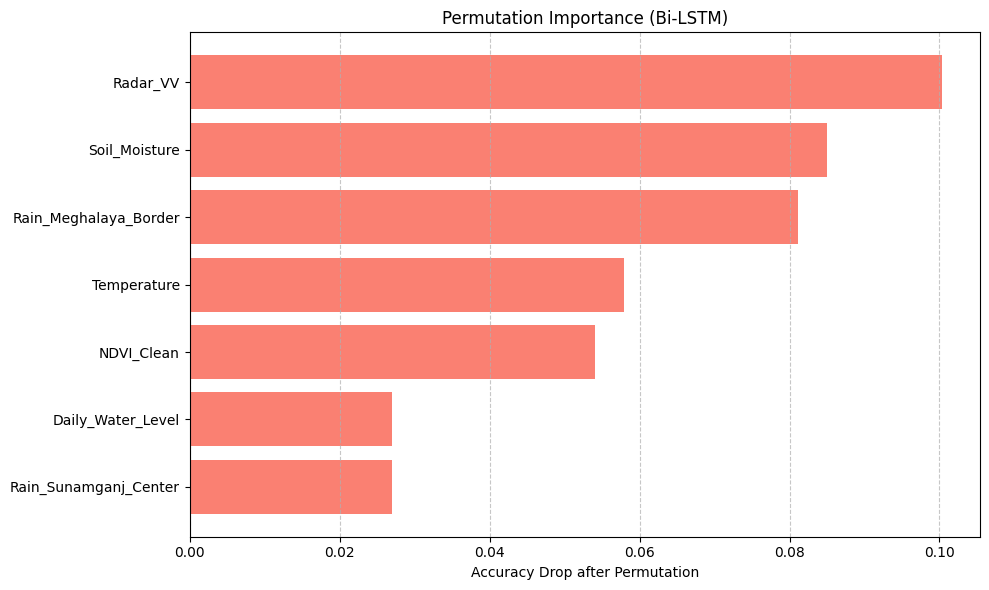

In [ ]:
def get_permutation_importance(model, X_val, y_val, feature_names):
    # বেসলাইন প্রেডিকশন
    y_pred_proba = model.predict(X_val)
    y_pred = np.argmax(y_pred_proba, axis=1)
    baseline_acc = accuracy_score(y_val, y_pred)

    importances = []
    for i in range(len(feature_names)):
        X_permuted = X_val.copy()
        # i-তম ফিচারের সব স্যাম্পল এবং সব টাইম-স্টেপ সাফল করা
        # এটি ফিচারের মধ্যকার রিলেশন নষ্ট করে দেবে
        save_col = X_permuted[:, :, i].copy()
        flat_col = save_col.flatten()
        np.random.shuffle(flat_col)
        X_permuted[:, :, i] = flat_col.reshape(save_col.shape)

        permuted_acc = accuracy_score(y_val, np.argmax(model.predict(X_permuted), axis=1))
        importances.append(baseline_acc - permuted_acc)

    return np.array(importances)

# গুরুত্ব ক্যালকুলেট এবং প্লট করা
p_importance = get_permutation_importance(model, X_val_f, y_val_f, feature_cols)

plt.figure(figsize=(10, 6))
indices = np.argsort(p_importance)
plt.barh([feature_cols[i] for i in indices], p_importance[indices], color='salmon')
plt.xlabel("Accuracy Drop after Permutation")
plt.title("Permutation Importance (Bi-LSTM)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**CNN_BILSTM**

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
from google.colab import files
import io

# --- ১. ডেটাসেট আপলোড ---
print("দয়া করে আপনার 'Agro_pulsedataset(verified).csv' ফাইলটি আপলোড করুন:")
uploaded = files.upload()
df = pd.read_csv(io.BytesIO(uploaded[list(uploaded.keys())[0]]))

# --- ২. ফিচার এবং টার্গেট সিলেকশন (আপনার দেওয়া ৭টি ফিচার) ---
feature_cols = [
    "NDVI_Clean", "Rain_Sunamganj_Center", "Rain_Meghalaya_Border",
    "Daily_Water_Level", "Soil_Moisture", "Temperature", "Radar_VV"
]
target_col = "Final_AgroPulse_Level"

# মিসিং ভ্যালু হ্যান্ডেলিং এবং স্কেলিং
df[feature_cols] = df[feature_cols].interpolate(method='linear').fillna(method='bfill')
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# --- ৩. সিকোয়েন্স তৈরির ফাংশন (১৪ দিন ইনপুট, ৭ দিন লিড টাইম) ---
SEQ_LEN = 14
LEAD_TIME = 7

def create_sequences(data, features, target, seq_len, lead_time):
    X_seq, y_seq = [], []
    feature_data = data[features].values
    target_data = data[target].values

    for i in range(len(data) - seq_len - lead_time + 1):
        X_seq.append(feature_data[i : i + seq_len])
        y_seq.append(target_data[i + seq_len + lead_time - 1])

    return np.array(X_seq), np.array(y_seq)

X, y = create_sequences(df, feature_cols, target_col, SEQ_LEN, LEAD_TIME)
print(f"\nডেটা প্রস্তুত। ইনপুট শেপ: {X.shape} (নমুনা, দিন, ফিচার)")

# --- ৪. কাস্টম Focal Loss (ইমব্যালেন্স ডেটার জন্য) ---
def sparse_categorical_focal_loss(alpha, gamma=2.0):
    alpha = np.array(alpha, dtype=np.float32)
    def focal_loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=len(alpha))
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        loss = alpha * K.pow(1 - y_pred, gamma) * (-y_true_one_hot * K.log(y_pred))
        return K.sum(loss, axis=-1)
    return focal_loss

# --- ৫. হাইব্রিড মডেল আর্কিটেকচার (CNN + Bi-LSTM) ---
def build_hybrid_model(input_shape, alpha_weights):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # 1D-CNN লেয়ার: লোকাল ফিচার বা প্যাটার্ন এক্সট্রাকশন
        layers.Conv1D(filters=32, kernel_size=3, padding='same', activation='relu'),
        layers.MaxPooling1D(pool_size=1),

        # Bidirectional LSTM লেয়ার: সময়ের দীর্ঘমেয়াদী প্রভাব বিশ্লেষণ
        layers.Bidirectional(layers.LSTM(64, return_sequences=False)),

        layers.Dropout(0.4),
        layers.Dense(32, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss=sparse_categorical_focal_loss(alpha=alpha_weights, gamma=2.0),
        metrics=['accuracy']
    )
    return model

# --- ৬. ১৪-ফোল্ড ক্রস-ভ্যালিডেশন ট্রেনিং ---
skf = StratifiedKFold(n_splits=14, shuffle=True, random_state=42)
fold_accuracies = []
y_true_all, y_pred_all = [], []

print("\n১৪-ফোল্ড ক্রস-ভ্যালিডেশন শুরু হচ্ছে...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # ক্লাস ওয়েট (Level 0: 1.0, Level 1: 2.0, Level 2: 5.0)
    alpha_weights = [1.0, 2.0, 5.0]
    model = build_hybrid_model((SEQ_LEN, len(feature_cols)), alpha_weights)

    model.fit(
        X_train, y_train,
        epochs=80, batch_size=64, verbose=0,
        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)]
    )

    preds = np.argmax(model.predict(X_val, verbose=0), axis=1)
    y_true_all.extend(y_val)
    y_pred_all.extend(preds)
    fold_accuracies.append(accuracy_score(y_val, preds))
    print(f"Fold {fold+1} সম্পন্ন - একিউরেসি: {fold_accuracies[-1]:.4f}")

# --- ৭. চূড়ান্ত রিপোর্ট ---
print("\n" + "="*60)
print(f"Hybrid CNN-BiLSTM গড় একিউরেসি: {np.mean(fold_accuracies):.4f} (± {np.std(fold_accuracies):.4f})")
print("="*60)
print(classification_report(y_true_all, y_pred_all, target_names=['Normal', 'Warning', 'Critical']))

দয়া করে আপনার 'Agro_pulsedataset(verified).csv' ফাইলটি আপলোড করুন:


Saving Agro_pulsedataset(verified).csv to Agro_pulsedataset(verified).csv

ডেটা প্রস্তুত। ইনপুট শেপ: (3633, 14, 7) (নমুনা, দিন, ফিচার)

১৪-ফোল্ড ক্রস-ভ্যালিডেশন শুরু হচ্ছে...



/tmp/ipykernel_274/3325096944.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[feature_cols] = df[feature_cols].interpolate(method='linear').fillna(method='bfill')
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


Fold 1 সম্পন্ন - একিউরেসি: 0.9923


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


...

Fold 12 সম্পন্ন - একিউরেসি: 0.9884


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


Fold 13 সম্পন্ন - একিউরেসি: 0.9846


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


Fold 14 সম্পন্ন - একিউরেসি: 0.9884

Hybrid CNN-BiLSTM গড় একিউরেসি: 0.9862 (± 0.0059)
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      3369
     Warning       0.91      0.89      0.90       250
    Critical       0.82      1.00      0.90        14

    accuracy                           0.99      3633
   macro avg       0.91      0.96      0.93      3633
weighted avg       0.99      0.99      0.99      3633

